# Plotting

bindcurve plotting is Axes-first: create your own Matplotlib `ax`, then let bindcurve draw observations, fitted curves, confidence bands, asymptotes, curve points, and residuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bindcurve as bc

rng = np.random.default_rng(123)

## Generate a small synthetic IC50 dataset

In [2]:
def ic50_curve(x, ymin=0.0, ymax=100.0, IC50=1.5, hill_slope=-1.1):
    return ymin + (ymax - ymin) / (1.0 + (IC50 / x) ** hill_slope)

concentrations = np.logspace(-2, 2, 12)
rows = []
for experiment_id, scale in {'exp1': 0.9, 'exp2': 1.0, 'exp3': 1.1}.items():
    for concentration in concentrations:
        response = ic50_curve(concentration, IC50=1.5 * scale)
        for replicate_id in range(1, 4):
            rows.append({
                'compound_id': 'compound_a',
                'experiment_id': experiment_id,
                'concentration': concentration,
                'replicate_id': f'rep{replicate_id}',
                'response': response + rng.normal(0, 2.0),
            })

data = bc.DoseResponseData.from_dataframe(pd.DataFrame(rows), concentration_unit='uM', response_unit='percent')
results = bc.fit(data, model='ic50', fixed={'ymin': 0.0, 'ymax': 100.0})

## Observations and fits as separate layers

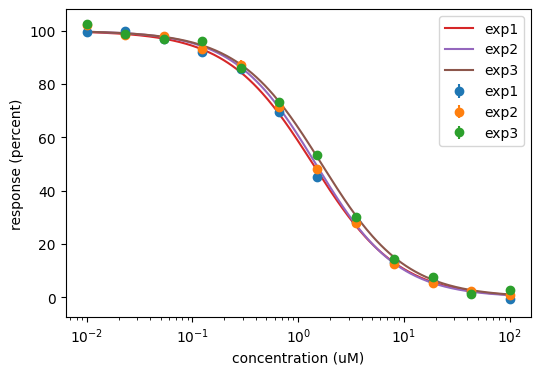

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_observations(data, ax=ax)
bc.plot_fits(data, results, ax=ax)
ax.legend()
plt.show()

## One-call plot with confidence bands and annotations

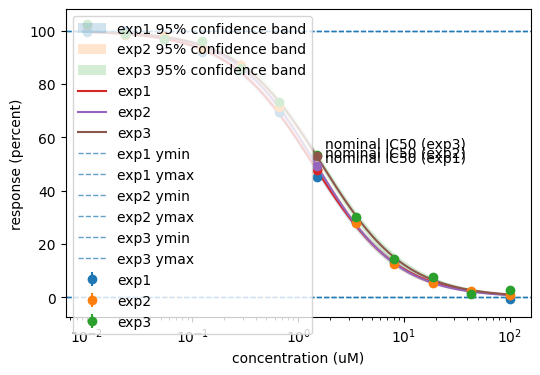

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_curves(
    data,
    results,
    ax=ax,
    confidence_band=True,
    show_asymptotes=True,
    curve_points=[(1.5, 'nominal IC50')],
)
ax.legend()
plt.show()

## Fully composed plot

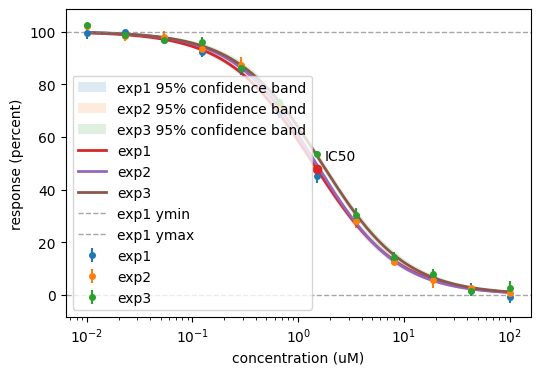

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
bc.plot_observations(data, ax=ax, error='sd', markersize=4)
bc.plot_confidence_bands(data, results, ax=ax, alpha=0.15)
bc.plot_fits(data, results, ax=ax, linewidth=2)
bc.plot_asymptotes(data, results, ax=ax, experiments=['exp1'], color='gray')
bc.plot_curve_points(data, results, ax=ax, experiments=['exp1'], points=[(1.5, 'IC50')])
ax.legend()
plt.show()

## Residual plot

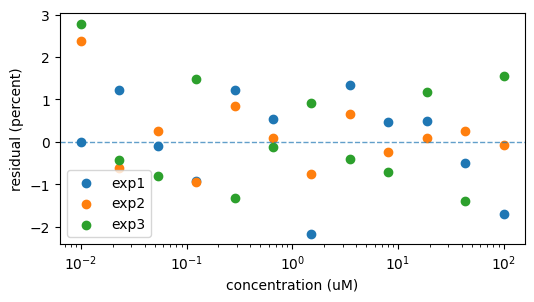

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
bc.plot_residuals(data, results, ax=ax)
ax.legend()
plt.show()